# Test en Machine Learning
## Prétraitement de données

### 1- faites les importations des bibliothèques nécessaires

In [22]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### 2- importer les données du fichier "dataset_ProjetML_2026.csv"

In [23]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### 3- afficher un échontillon du dataframe

In [24]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### 4- afficher toutes les variables du dataset et leurs types respectifs

In [25]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

In [26]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### 5-Afficher le nombre de lignes et de colonnes du dataframe

In [28]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


In [29]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [30]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

In [31]:
duplicates = df[df.duplicated()]
len(duplicates)


776

In [32]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


In [33]:
df.duplicated(subset=df.columns).sum()

np.int64(776)

In [34]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

In [35]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)

0

In [36]:
df = df.drop_duplicates().reset_index(drop=True)

In [37]:
feature_cols = df.columns.drop('Categorie')

df_conflict = df[df.duplicated(subset=feature_cols, keep=False)]

In [38]:
duplicates = df[df.duplicated()]
len(duplicates)


0

In [39]:
df.shape

(9724, 9)

In [40]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### 6- Quelles sont les colonnes qui  contiennent des valeurs nulls ? Endéduire le nombre de valeurs nulls

In [41]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


### 7-remplacer les valeurs manquantes dans la colonne "" par la moyenne de la colonne

In [42]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

In [43]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [44]:
print(df.isna().sum())

Poids                 0
Volume                0
Conductivite          0
Opacite               0
Rigidite              0
Prix_Revente          0
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


### Catégorielle

In [45]:
print(df["Categorie"].mode())
print(df["Source"].mode())


0    Plastique
Name: Categorie, dtype: object
0    Collecte_Citoyenne
Name: Source, dtype: object


In [46]:
cat_cols = df.select_dtypes(include=['object']).columns


In [47]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [48]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


### 9- Sachant que la colonne "" est la cible, déduire si le dataset est équilibré ou non?

In [49]:
df["Categorie"].value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [50]:
#OUI la dataset est globalement équilibré car Les classes ne sont pas très éloignées

In [51]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

<Axes: >

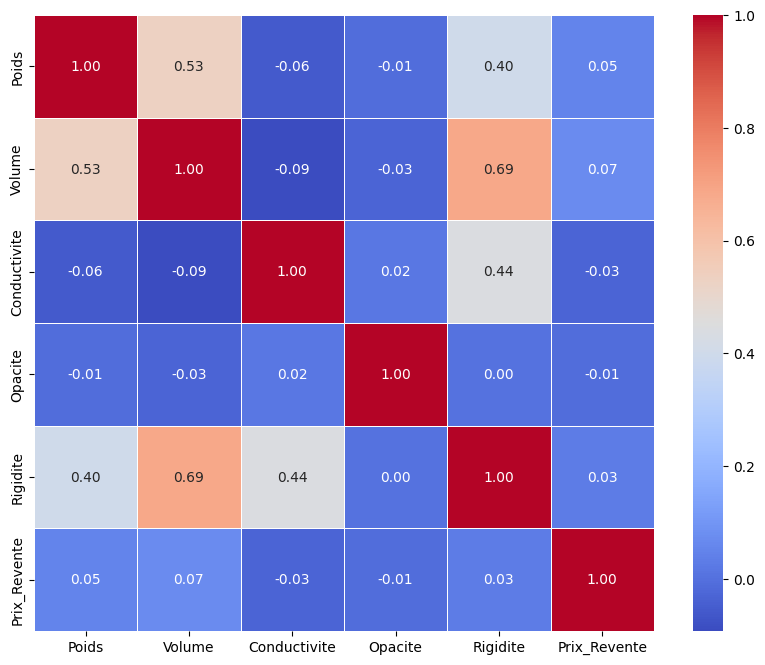

In [52]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

### 11- Chercher les colonnes qui ont des valeurs abbérantes en affichant le boxplot pour tout le dataset

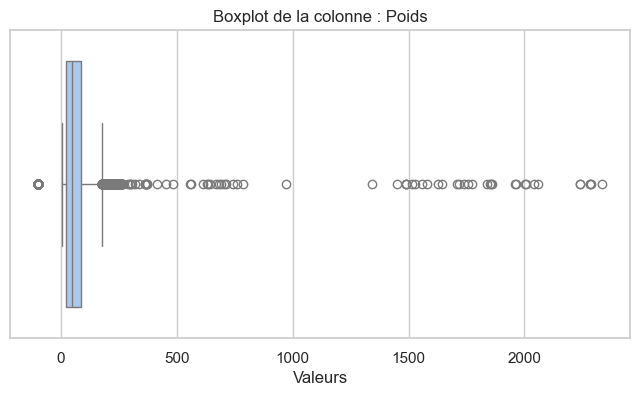

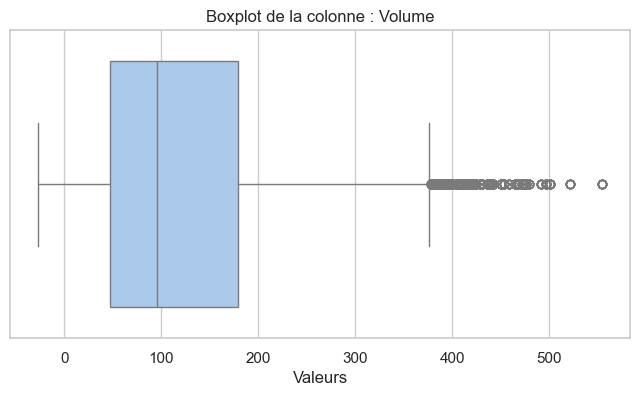

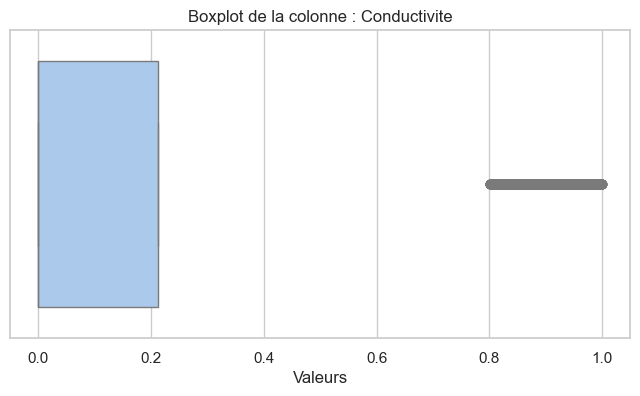

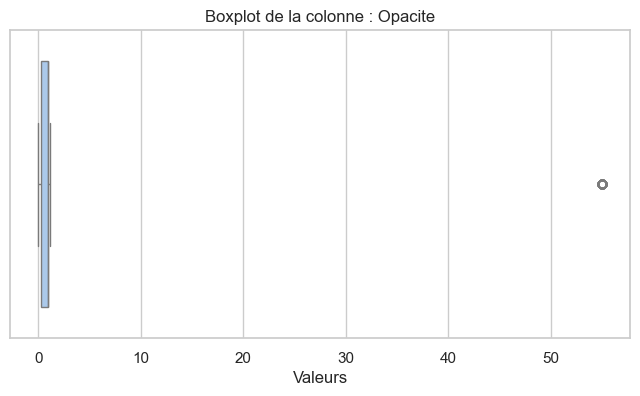

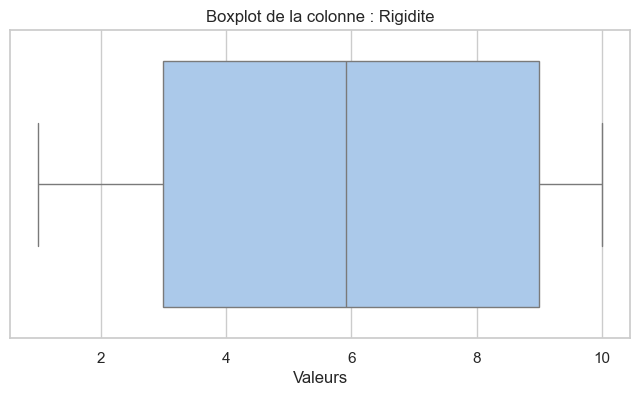

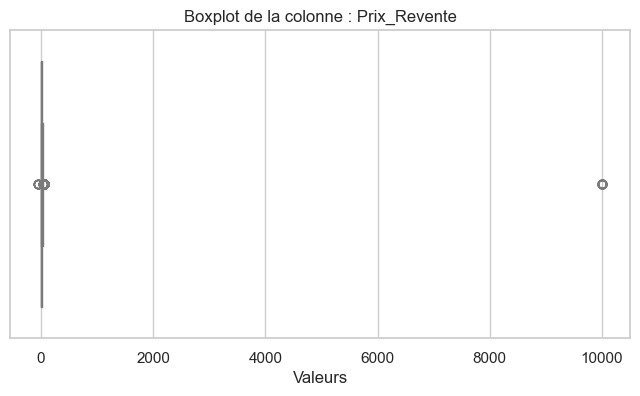

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

In [54]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


### 12- Nous allons traiter les valeurs abbérantes que la colonne "" en remplaçant ces valeurs par la médiane

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [55]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR


#### b-remplacer les VA par la mediane de la colonne

In [56]:
outliers = df[(df['Poids'] < inf) | (df['Poids'] > sup)]
print(outliers)
for i in df['Poids']:
    if i >=sup or i<=inf:
        df['Poids']=df['Poids'].replace(i,np.median(df['Poids']))

            Poids      Volume  Conductivite    Opacite   Rigidite  \
21    2288.584664  430.114904      0.000000   0.172473   8.000000   
305   1489.027225  324.066815      0.000000   0.195122   9.000000   
389   1754.749314  346.209879      0.000000   0.146490  10.000000   
1332  1559.252180  337.826663      0.000000   0.059307  10.000000   
1463   368.786333   82.150577      0.212821   0.200842   4.000000   
1488  1773.491112  347.298002      0.000000   0.032005   9.000000   
1676  2060.746819  429.895181      0.000000   0.104290  10.000000   
2118  1707.664315  328.354895      0.000000   0.161486   5.921374   
2298  1580.173911  302.001344      0.000000   0.034751   9.000000   
2734  1860.616385  385.171051      0.000000   0.010878  10.000000   
3236   610.949513  137.791466      0.212821   1.000000   7.000000   
3363  1528.889442  312.265074      0.000000   0.135236   9.000000   
3517  1739.775251  323.312204      0.000000   0.041837  10.000000   
3624   971.681410  144.672063     

#### c-vérifier la modification des VA

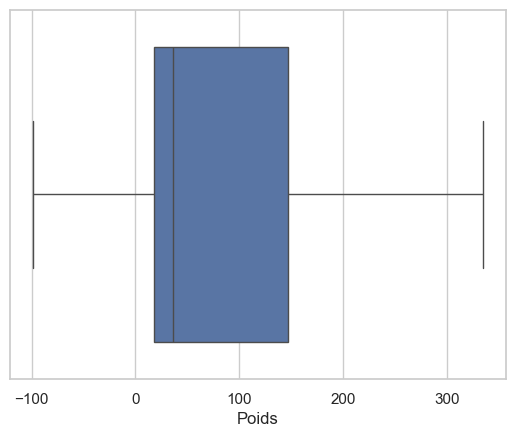

In [57]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

### 13- supprimer les VA de la colonne ''

In [58]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


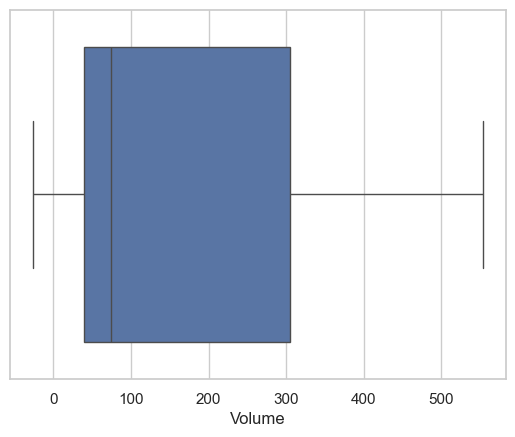

In [59]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

### *13- Traiter les VA de la colonne 

In [60]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


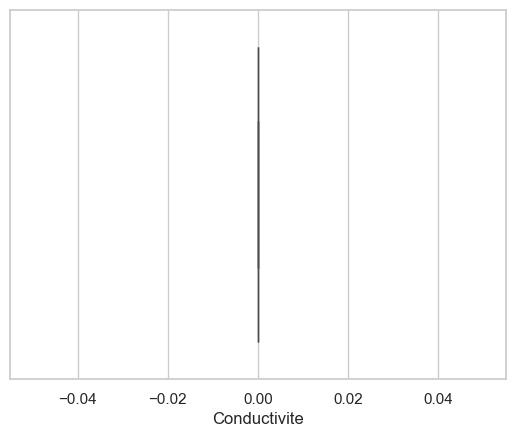

In [61]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

In [62]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


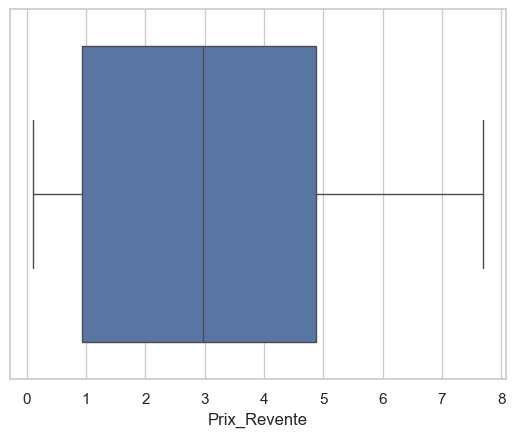

In [63]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

Text(0, 0.5, 'Volume')

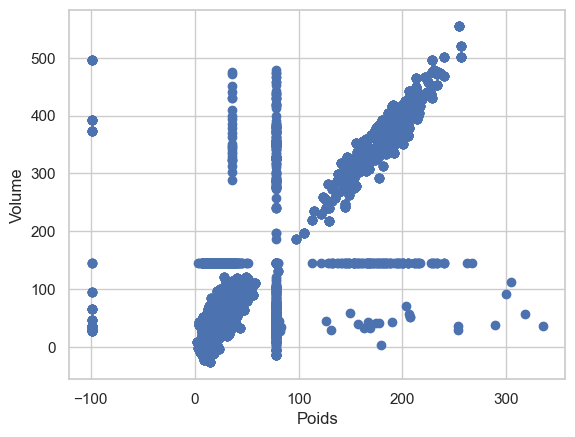

In [64]:
plt.scatter(x=df['Poids'],y=df['Volume'])
plt.xlabel('Poids')
plt.ylabel('Volume')


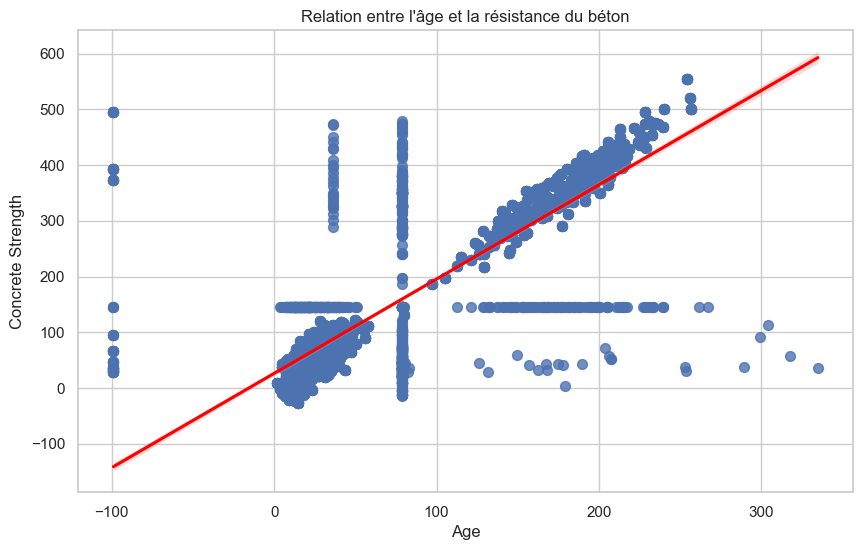

In [65]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre l\'âge et la résistance du béton')
plt.xlabel('Age')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

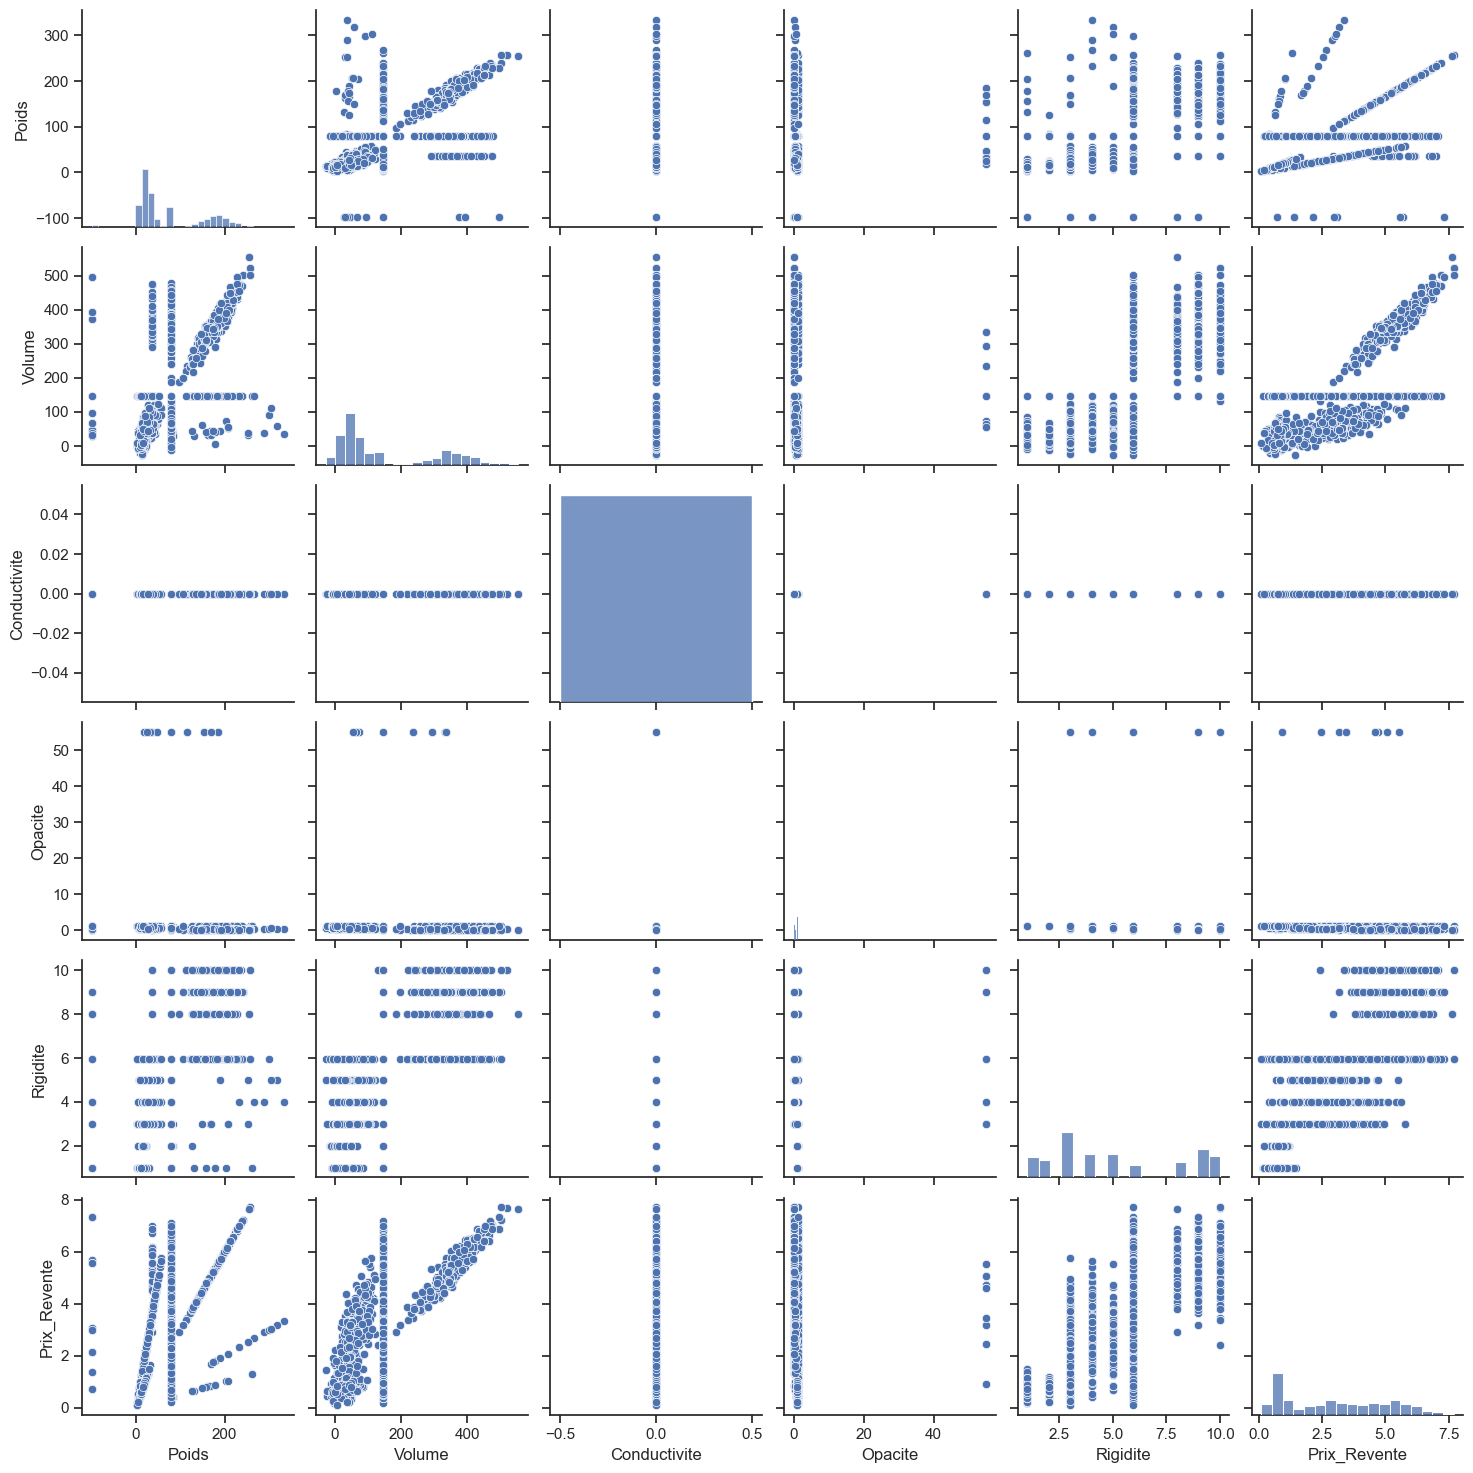

In [66]:
sns.set(style='ticks')
sns.pairplot(df)

### 14- affecter à Y (cible) la dernière colonne () et le reste du dataframe au entrées X

In [67]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 6263, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite   Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000   1.000000      0.835439   
1      47.277476   64.702925           0.0  1.165074   3.000000      4.727748   
2      78.581580  317.415183           0.0  1.165074   9.000000      4.211790   
3      78.581580   21.474391           0.0  1.165074   1.000000      0.442067   
4      78.581580   59.462176           0.0  1.000000   5.921374      0.723004   
...          ...         ...           ...       ...        ...           ...   
9719  191.018619  418.800912           0.0  0.019307   9.000000      5.730559   
9720  149.052713  287.519460           0.0  0.157940  10.000000      4.471581   
9721 

In [68]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 6263, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite   Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000   1.000000     Papier   
1      47.277476   64.702925           0.0  1.165074   3.000000  Plastique   
2      78.581580  317.415183           0.0  1.165074   9.000000      Verre   
3      78.581580   21.474391           0.0  1.165074   1.000000     Papier   
4      78.581580   59.462176           0.0  1.000000   5.921374     Papier   
...          ...         ...           ...       ...        ...        ...   
9719  191.018619  418.800912           0.0  0.019307   9.000000      Verre   
9720  149.052713  287.519460           0.0  0.157940  10.000000      Verre   
9721   15.572667   50.148243           

In [69]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [70]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
674    29.764478   56.041872           0.0  0.237050       5.0      2.976448   
5630  105.350179  197.535391           0.0  0.032244       9.0      3.160505   
6948   33.869653  144.672063           0.0  0.472390       5.0      3.386965   
286    78.581580  398.684805           0.0  0.088482       9.0      6.445731   
2565   16.924256   37.681730           0.0  0.383439       5.0      1.692426   

                  Source  
674              Usine_A  
5630  Collecte_Citoyenne  
6948          Centre_Tri  
286              Usine_B  
2565          Centre_Tri  

Echantillon de Y :
4164        Verre
4910    Plastique
8405        Verre
3144    Plastique
2468    Plastique
Name: Categorie, dtype: object


In [71]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
          Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
1874  36.729432   38.166946           0.0  1.165074       5.0  Plastique   
8090  34.258872   68.900700           0.0  0.502924       3.0  Plastique   
8697  27.634196   47.340516           0.0  0.515161       3.0  Plastique   
4800  46.582074  108.889999           0.0  0.345868       5.0  Plastique   
8096  12.816401   24.310150           0.0  1.000000       3.0     Papier   

                  Source  
1874             Usine_A  
8090             Usine_B  
8697          Centre_Tri  
4800  Collecte_Citoyenne  
8096             Usine_B  

Echantillon de Y :
2096    1.330221
4738    0.662245
4060    3.884101
6020    5.299897
2716    0.496671
Name: Prix_Revente, dtype: float64


### 17- transformer les colonnes catégoriques en numérique

In [72]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [73]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [74]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)

X_regg = ct.fit_transform(X_regg)

### - Transformer X et Y en tableau numpy

In [75]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)

print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (6263, 10)
Shape de Y : (6263,)


In [76]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (6263, 12)
Shape de Y : (6263,)


### 18- Vérifier cette transformation

In [77]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 1.16507449e+00,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.85815802e+01, 3.17415183e+02, 0.00000000e+00, 1.16507449e+00,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        7.85815802e+01, 2.14743907e+01, 0.00000000e+00, 1.16507449e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        7.85815802e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        5.92137405e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [78]:
Y_class

array([0, 1, 2, ..., 0, 1, 2])

In [79]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087799e+01,
        7.09409765e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.72774763e+01,
        6.47029253e+01, 0.00000000e+00, 1.16507449e+00, 3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 7.85815802e+01,
        3.17415183e+02, 0.00000000e+00, 1.16507449e+00, 9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.85815802e+01,
        2.14743907e+01, 0.00000000e+00, 1.16507449e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.85

In [80]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### 19- Subdiviser la dataset en deux parties train et test

In [81]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (5010, 10)
x_test: (1253, 10)
y_train: (5010,)
y_test: (1253,)
y_train mean: 1.0387225548902195
y_test mean: 1.0071827613727056


In [82]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (5010, 12)
x_test: (1253, 12)
y_train: (5010,)
y_test: (1253,)
y_train: 3.105557235931464
y_test: 3.0438813456927813


### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [83]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [84]:
print(x_train[:5])

[[-0.5344196  -0.67745111  1.72424977 -0.51802937 -0.88899937 -0.84401423
   0.         -0.02362371 -1.40285955 -1.35847362]
 [ 1.87118885 -0.67745111 -0.57996238 -0.51802937 -0.65035804 -0.5559752
   0.         -0.11718315 -0.39206874 -0.28910755]
 [-0.5344196  -0.67745111  1.72424977 -0.51802937  1.35421297  1.34193459
   0.         -0.20045072  1.62951289  1.08204112]
 [-0.5344196  -0.67745111  1.72424977 -0.51802937 -0.4707401  -0.30567812
   0.         -0.09594931 -0.39206874  0.3813474 ]
 [-0.5344196  -0.67745111 -0.57996238  1.93039247  0.91282412  0.87031861
   0.         -0.17420573  0.95565235  0.5877731 ]]


In [85]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [86]:
print(x_train_reg[:5])

[[-0.5344196  -0.67745111  1.72424977 -0.51802937  1.58924074 -0.80634833
  -0.68970976 -0.88899937 -0.84401423  0.         -0.02362371 -1.40285955]
 [ 1.87118885 -0.67745111 -0.57996238 -0.51802937 -0.62923129  1.24015883
  -0.68970976 -0.65035804 -0.5559752   0.         -0.11718315 -0.39206874]
 [-0.5344196  -0.67745111  1.72424977 -0.51802937 -0.62923129 -0.80634833
   1.44988523  1.35421297  1.34193459  0.         -0.20045072  1.62951289]
 [-0.5344196  -0.67745111  1.72424977 -0.51802937 -0.62923129  1.24015883
  -0.68970976 -0.4707401  -0.30567812  0.         -0.09594931 -0.39206874]
 [-0.5344196  -0.67745111 -0.57996238  1.93039247 -0.62923129 -0.80634833
   1.44988523  0.91282412  0.87031861  0.         -0.17420573  0.95565235]]


# Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [87]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report
import numpy as np

# --- Imputation des NaN (remplacement par la moyenne de chaque colonne) ---
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test  = imputer.transform(x_test)       # transform seulement, pas fit !

# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))

# --- Aperçu des 10 premières prédictions ---
print("\nAperçu des 10 premières prédictions:")
for i in range(10):
    print(f"  [{i}] Vérité: {y_test_eval[i]}  →  Prédiction: {y_pred_knn[i]}")


Confusion Matrix:
 [[369   6   0]
 [ 18 460  16]
 [  0   4 380]]

Accuracy  : 0.9649
Recall    : 0.9683
Precision : 0.9639

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       375
           1       0.98      0.93      0.95       494
           2       0.96      0.99      0.97       384

    accuracy                           0.96      1253
   macro avg       0.96      0.97      0.97      1253
weighted avg       0.97      0.96      0.96      1253


Aperçu des 10 premières prédictions:
  [0] Vérité: 2  →  Prédiction: 2
  [1] Vérité: 1  →  Prédiction: 1
  [2] Vérité: 1  →  Prédiction: 1
  [3] Vérité: 1  →  Prédiction: 1
  [4] Vérité: 1  →  Prédiction: 1
  [5] Vérité: 0  →  Prédiction: 0
  [6] Vérité: 0  →  Prédiction: 0
  [7] Vérité: 1  →  Prédiction: 1
  [8] Vérité: 1  →  Prédiction: 1
  [9] Vérité: 0  →  Prédiction: 0


# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [88]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 7}
Meilleur score     : 0.9631061593187729

Confusion Matrix KNN optimisé:
 [[370   5   0]
 [ 22 455  17]
 [  0   1 383]]
Accuracy  : 0.9641
Recall    : 0.9684
Precision : 0.9628

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       375
           1       0.99      0.92      0.95       494
           2       0.96      1.00      0.98       384

    accuracy                           0.96      1253
   macro avg       0.96      0.97      0.96      1253
weighted avg       0.97      0.96      0.96      1253



# Decision Tree

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[373   2   0]
 [ 21 457  16]
 [  0   2 382]]
Accuracy  : 0.9673
Recall    : 0.9715
Precision : 0.9659

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       375
           1       0.99      0.93      0.96       494
           2       0.96      0.99      0.98       384

    accuracy                           0.97      1253
   macro avg       0.97      0.97      0.97      1253
weighted avg       0.97      0.97      0.97      1253



## Importance des features

# Random Forest

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[374   1   0]
 [ 17 461  16]
 [  0   9 375]]
Accuracy  : 0.9657
Recall    : 0.9690
Precision : 0.9648

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       375
           1       0.98      0.93      0.96       494
           2       0.96      0.98      0.97       384

    accuracy                           0.97      1253
   macro avg       0.96      0.97      0.97      1253
weighted avg       0.97      0.97      0.97      1253



In [91]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [92]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(classification_report(y_test, y_predictSVM_l))

[[369   6   0]
 [ 41 437  16]
 [  0   1 383]]
Accuracy linear SVM 0.949
Precision linear SVM 0.948
Recall linear SVM 0.955
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       375
           1       0.98      0.88      0.93       494
           2       0.96      1.00      0.98       384

    accuracy                           0.95      1253
   macro avg       0.95      0.96      0.95      1253
weighted avg       0.95      0.95      0.95      1253



# Logistic Regression

In [93]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [94]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))

[[365  10   0]
 [ 40 438  16]
 [  0   5 379]]
Accuracy Logistic Regression 0.943
Precision Logistic Regression 0.943
Recall Logistic Regression 0.949


# Sommary

In [95]:
print("| Algorithm         | Accuracy   | Recall     | Precision  |")
print("| ----------------- | ---------- | ---------- | ---------- |")
print("| Optimized kNN     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(knn_op_acc, knn_op_rec, knn_op_prec))
print("| Decision Tree     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(accur_dt, rec_dt, pres_dt))
print("| Random Forest     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(rf_acc, rf_rec, rf_prec))
print("| Linear SVM        | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(svm_acc, svm_rec, svm_prec))
print("| Logistic Reg      | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(LR_acc, LR_rec, LR_prec))

| Algorithm         | Accuracy   | Recall     | Precision  |
| ----------------- | ---------- | ---------- | ---------- |
| Optimized kNN     | 0.964    | 0.968    | 0.963    |
| Decision Tree     | 0.967    | 0.972    | 0.966    |
| Random Forest     | 0.966    | 0.969    | 0.965    |
| Linear SVM        | 0.949    | 0.955    | 0.948    |
| Logistic Reg      | 0.943    | 0.949    | 0.943    |


# Ajouter F1 score 


In [96]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# Probabilités de la classe positive
y_score = model.predict_proba(x_test)[:, 1]

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Affichage
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Classification binaire")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

NameError: name 'X' is not defined

# Regression

In [97]:
# =========================================================
# 1) Importation des bibliothèques
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 2) Charger le dataset
# =========================================================
df = pd.read_csv("dataset_ProjetML_2026.csv")

print("Dimensions du dataset :", df.shape)
print(df.head())

# =========================================================
# 3) Supprimer les lignes où la cible est manquante
# =========================================================
df = df.dropna(subset=["Prix_Revente"]).copy()

# =========================================================
# 4) Définir X et y
# =========================================================
X = df.drop("Prix_Revente", axis=1)
y = df["Prix_Revente"]

# =========================================================
# 5) Définir les colonnes
# =========================================================
numeric_features = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
categorical_features = ["Categorie", "Source"]
text_feature = "Rapport_Collecte"

# =========================================================
# 6) Prétraitement
# =========================================================

# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline pour la colonne texte
text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=300))
])

# Combinaison de tous les prétraitements
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("txt", text_transformer, text_feature)
])

# =========================================================
# 7) Division Train / Test
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 8) Définir plusieurs modèles de régression
# =========================================================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# =========================================================
# 9) Entraîner et évaluer chaque modèle
# =========================================================
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modele": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })
    
    print(f"\n===== {name} =====")
    print("MAE  =", mae)
    print("MSE  =", mse)
    print("RMSE =", rmse)
    print("R2   =", r2)

# =========================================================
# 10) Tableau comparatif des résultats
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\nTableau des performances :")
print(results_df)

# =========================================================
# 11) Choisir le meilleur modèle
# =========================================================
best_model_name = results_df.iloc[0]["Modele"]
print("\nMeilleur modèle :", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

# =========================================================
# 12) Prédictions sur l'ensemble de test
# =========================================================
y_pred_best = best_pipeline.predict(X_test)

# =========================================================
# 13) Générer une nouvelle colonne avec le prix prédit
# =========================================================
X_test_result = X_test.copy()
X_test_result["Prix_Revente_Reel"] = y_test.values
X_test_result["Prix_Revente_Predit"] = y_pred_best

print("\nAperçu des prédictions :")
print(X_test_result.head())

# =========================================================
# 14) Sauvegarder le résultat dans un fichier CSV
# =========================================================
X_test_result.to_csv("resultats_regression_prix_revente.csv", index=False)

print("\nFichier sauvegardé : resultats_regression_prix_revente.csv")

Dimensions du dataset : (10500, 9)
       Poids      Volume  Conductivite  Opacite  Rigidite  Prix_Revente  \
0  16.708780   70.940977           0.0      1.0       1.0      0.835439   
1  47.277476   64.702925           0.0      NaN       3.0      4.727748   
2        NaN  317.415183           0.0      NaN       9.0      4.211790   
3        NaN   21.474391           0.0      NaN       1.0      0.442067   
4        NaN   59.462176           0.0      1.0       NaN      0.723004   

   Categorie      Source                                   Rapport_Collecte  
0     Papier         NaN  Lot de papier récupéré dans un site non rensei...  
1  Plastique     Usine_A  Lot plastique à l'Usine A. Volume 64.7 L, poid...  
2      Verre     Usine_B  Bris de verre ou contenants en provenance de l...  
3     Papier  Centre_Tri  Feuilles et cartons collectés au Centre de Tri...  
4     Papier     Usine_B  Déchet de type papier identifié à l'Usine B. V...  

===== LinearRegression =====
MAE  = 165.21271

# Régression linéaire

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.008119044478171245
MAE   : 129.10540604480843
MSE   : 690894.7587506416
RMSE  : 831.2007932808062
MAPE  : 25.873408299695406
MEDAE : 46.66904845609519
          0         1         2         3         4         5         6  \
0 -0.541437 -0.664191 -0.566581  1.860255  1.880614 -0.533294 -0.674015   
1 -0.541437 -0.664191  1.764972 -0.537561  1.880614 -0.533294 -0.674015   
2 -0.541437  1.505591 -0.566581 -0.537561 -0.531741 -0.533294  1.483646   
3 -0.541437 -0.664191  1.764972 -0.537561 -0.531741 -0.533294 -0.674015   
4  1.846938 -0.664191 -0.566581 -0.537561 -0.531741 -0.533294 -0.674015   

          7         8         9        10        11        12    prix_reel  \
0 -0.570831 -0.451166 -0.961265  1.906914 -0.026711  0.697868     6.672856   
1 -0.570831 -0.335028 -0.311799  1.766505 -0.026711  1.029330    10.973280   
2 -0.570831 -0.522848 -0.614556 -0.578895 -0.140902 -0.959442     1.339517   
3  1.751831  1.407831  2.622586 -0.578895 -0

# Coefficients

# Clustering

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [100]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

X = df[cols]

In [101]:
X = X.dropna()

In [102]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow Method

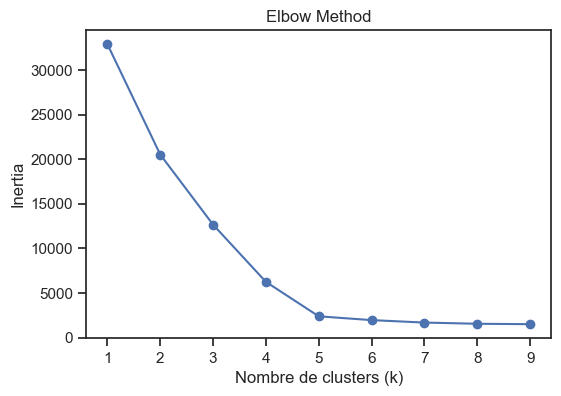

In [103]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Clustering KMeans

In [104]:
k = 3  

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter au dataframe original (aligner index)
df = df.loc[X.index]
df["Cluster"] = clusters

Analyse des clusters

In [105]:
cluster_analysis = df.groupby("Cluster")[cols].mean()
print(cluster_analysis)

              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0         22.508882   47.497369      0.000000  1.086853  3.049925
1         60.729504  120.161900      0.895555  1.281617  8.610169
2        203.447262  361.949684      0.001574  1.039529  9.130742


Visualisation PCA

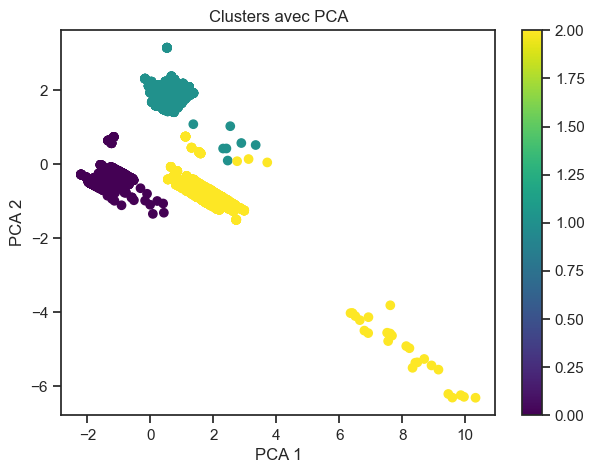

In [106]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

Silhouette

In [107]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.7346943221018394


Comparaison avec vraie catégorie

In [108]:
if "Categorie" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Categorie"]))

Categorie  Métal  Papier  Plastique  Verre
Cluster                                   
0              0    1465       1714      0
1           1454       0          0      0
2              3       0          0   1620


Visualisation

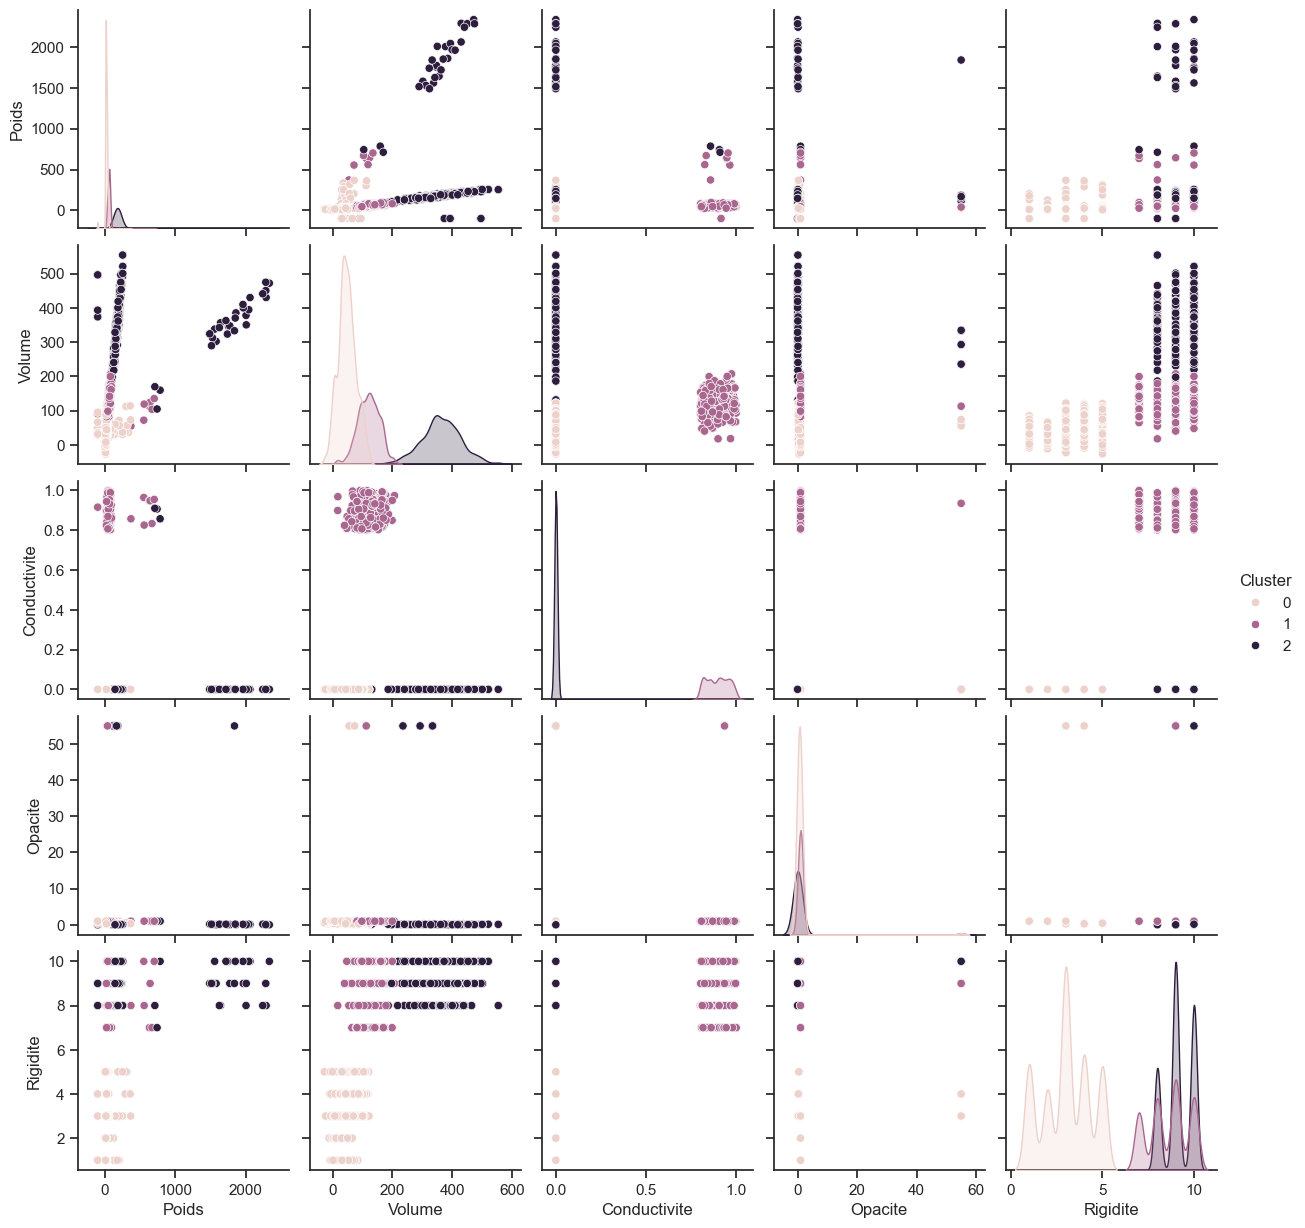

In [109]:
sns.pairplot(df, hue="Cluster", vars=cols)
plt.show()